<a href="https://colab.research.google.com/github/anferivera/Fisica_Computacional_1/blob/main/2_finite_differece_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Librery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Exercise 1: Lab1_3: finite-differences with tolerance

* Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
* Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
* Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

**Estrategia con tolerancia (explicado simple):**

En lugar de elegir “cuántas iteraciones hacer”, se elige una **tolerancia** `tol`, que es el nivel de cambio que acepto como “ya no está cambiando de forma importante”. El algoritmo va actualizando la malla usando el promedio de los vecinos (relajación) y, después de cada barrido completo, compara la solución nueva con la anterior. Si en toda la malla el cambio máximo es menor que `tol`, se considera que la solución **ya convergió** y se detiene. Para evitar quedarse corriendo para siempre si algo no converge, también se pone un `max_iter` como límite de seguridad.


In [5]:
def Laplace2D(V_ini, x, y, tol=1e-3, max_iter=1000):

  Nmax = V_ini.shape[0]
  V = V_ini.copy()

  for _ in range(int(max_iter)):
    # Comparación con el valor anterior para evaluar convergencia de la solución
    V_prev = V.copy()
    
    # Iteración sobre el grid
    for i in range(1, Nmax - 1):
      for j in range(1, Nmax - 1):
        V[i, j] = 0.25 * (V[i + 1, j] + V[i - 1, j] + V[i, j + 1] + V[i, j - 1])

    # Tolerancia
    err = np.max(np.abs(V - V_prev))
    if err < tol:
      break

  X, Y = np.meshgrid(x, y)
  Z = V[X, Y]

  return X, Y, Z


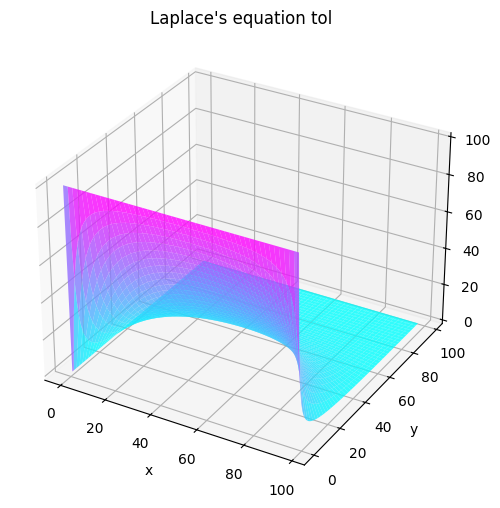

In [13]:
#Initial V matrix
Nmax = 100
tol = 1e-3

V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100.0 # let line at 100V


x = np.arange(0, Nmax-1, 1)
y = x

# #Run Laplace2D rutine
X, Y, Z = Laplace2D(V_ini, x, y)

#Plot the field

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation tol')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()


En lugar de elegir el número de iteraciones como breakpoint de la solución, se elige una tolerancia `tol`, que es el nivel de cambio que acepto como la convergencia de la solución (ya no está cambiando de forma importante). El algoritmo va actualizando la malla usando el promedio de los vecinos (relajación) y, después de cada barrido completo, compara la solución nueva con la anterior. Si en toda la malla el cambio máximo es menor que `tol`, se considera que la solución ya convergió y se detiene. Para evitar quedarse corriendo para siempre si algo no converge, también se pone un `max_iter` como límite de seguridad.


#### Exercise 2: Lab1_4: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

In [ ]:
#********************************************************************
def Laplace2D(V_ini,Niter,x,y):
  '''Int the V initial configutaration.\n Niter is the number of the itertions of the algorithm.
  x(y) the array in x(y) variable.
  Return X,Y,Z evolve Niter times using finite differences for the Laplace case.'''

  Nmax = V_ini.shape[0]
  V = V_ini.copy()

  for iter in range(Niter): # iterations over algorithm. Niter times
    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

  X, Y = np.meshgrid(x,y)

  Z = V[X,Y] #filed value
  #retunr grid
  return X,Y,Z

### Example 2: Electric field in a capacitor

in process...

## 2. Diffusion equation

\begin{align}
\boxed{
\nabla^2 u(x,y,t)= \dfrac{\partial^2 u(x,y,t)}{\partial x^2} +\dfrac{\partial^2 u(x,y,t)}{\partial y^2}= \dfrac{1}{\alpha}\dfrac{\partial u(x,y,t)}{\partial t}}
\end{align}

Where $1/\alpha$ is the diffusion coefficient. Here, we will express derivatives in terms of finite differences in the values of $u$ at the laticce sites. For space coordinates in 2D:


\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} \approx& \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2} +  \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2} \,.
\end{align}

For time:
* Derivate to the right:
\begin{align}
u(x,y,t+\Delta t) = u(x,y,t) + \dfrac{\partial u}{\partial t}\Delta t + \dfrac{1\partial^2 u}{2\partial t^2}(\Delta t)^2 + \cdots
\end{align}
* Derivate to the left:
\begin{align}
u(x,y,t-\Delta t) = u(x,y,t) - \dfrac{\partial u}{\partial t}\Delta t + \dfrac{1\partial^2 u}{2\partial t^2}(\Delta t)^2 + \cdots\,,
\end{align}
* Central derivative:
\begin{align}
\dfrac{\partial u}{\partial t} \approx \dfrac{u(x,y,t+\Delta t) -u(x,y,t-\Delta t)}{2\Delta t} \,.
\end{align}

Let's suppose $\Delta x=\Delta y$, $x_i=x_0+i\Delta$, $y_j=y_0+j\Delta$, $t_k=k\Delta t$, $\{i,j,k\}=0,\cdots N$. Using the derivative to the right in time, the Diffusion's equation can be writeen as:

\begin{align}
\dfrac{\big[ u_{i+1,j,k}+u_{i-i,j,k} +
u_{i,j+1,k}+u_{i,j-1,k} -4u_{i,j,k} \big]}{\Delta^2}
= \dfrac{1}{\alpha}\dfrac{\big(u_{i,j,k+1}-u_{i,j,k}\big)}{\Delta t}\,,
\end{align}
and the state of the system at time step $k$ may be calculated from its state at time step $k$ as:

\begin{align}
\boxed{
u_{i,j,k+1}=u_{i,j,k}+\alpha\Delta t\,\dfrac{\big[ u_{i+1,j,k}+u_{i-i,j,k} +
u_{i,j+1,k}+u_{i,j-1,k} -4u_{i,j,k} \big]}{\Delta^2}} \,.
\end{align}



### Example 1: Heat diffusion in a plate

Consider the diffusion equation applied to a metal plate initially at temperature $T_\text{cold}$  apart from a disc of a specified size which is at temperature $T_\text{hot}$. We suppose that the edges of the plate are held fixed at $T_\text{cold}$. The following code applies the above formula to follow the evolution of the temperature of the plate.

In the code below, each call to `do_timestep` updates the numpy array u from the results of the previous timestep, `u0`. It does not apply directly the algorithm because this runs extremely slowly and using vectorization will farm out these explicit loops to the much faster pre-compiled C-code underlying NumPy's array implementation.

The state of the system is plotted as an image at four different stages of its evolution.

Taken from: https://scipython.com/books/book2/chapter-7-matplotlib/examples/the-two-dimensional-diffusion-equation/


dt= 0.0006250000000000001

figure of 10x10, circle of radio 2 initial a 700K. The system evolve 62.5 ms


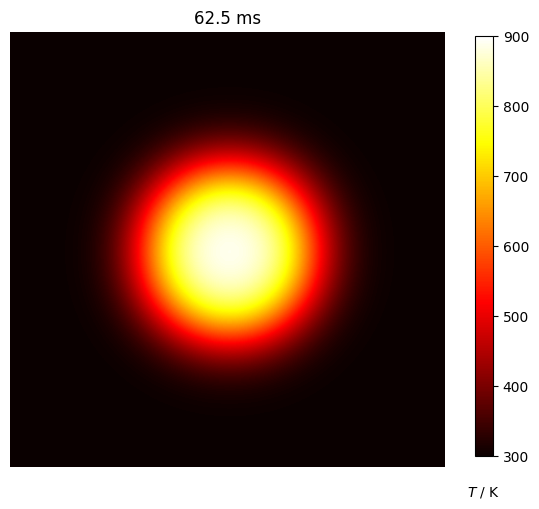

In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt

# plate size, mm
w = h = 10.0
# intervals in x-, y- directions, mm
dx = dy = 0.1
# Thermal diffusivity of steel, mm2.s-1
D = 4.0 #D=1/alpha

Tcool, Thot = 300, 900

nx, ny = int(w / dx), int(h / dy)

dx2, dy2 = dx*dx, dy*dy
dt = dx2*dy2 / (2*D*(dx2 + dy2)) #maximun t allowed
print('dt=',dt)

u0 = Tcool*np.ones((nx, ny)) #init grid (100x100) in 300K
u = u0.copy()

# Initial conditions: circle of radius r centred at (cx,cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2
for i in range(nx):
    for j in range(ny):
        p2 = (i * dx - cx) ** 2 + (j * dy - cy) ** 2
        if p2 < r2:
            u0[i, j] = Thot

def do_timestep(u0, u):
    # Propagate with forward-difference in time, central-difference in space. Notice that dx=dy
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D*dt*(u0[2:, 1:-1] - 4 * u0[1:-1, 1:-1] + u0[:-2, 1:-1] + u0[1:-1, 2:] + u0[1:-1, :-2])/dx2

    u0 = u.copy()
    return u0, u

# Number of times teps with dt=0.000625
nsteps = 101
# timesteps.
mfig = 50
fig, ax = plt.subplots(figsize=(6,6) )
for m in range(nsteps): #propagate the signal
    u0, u = do_timestep(u0, u)

im = ax.imshow(u.copy(),cmap="hot",vmin=Tcool,vmax=Thot,interpolation="bilinear",)
ax.set_axis_off()
ax.set_title("{:.1f} ms".format(m*dt*1000))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
print('\nfigure of 10x10, circle of radio 2 initial a 900K. The system evolve 62.5 ms')
plt.show()

This system analytical needs the Bessel funtions to do the Fourier series. Let's plot for 4 different times.

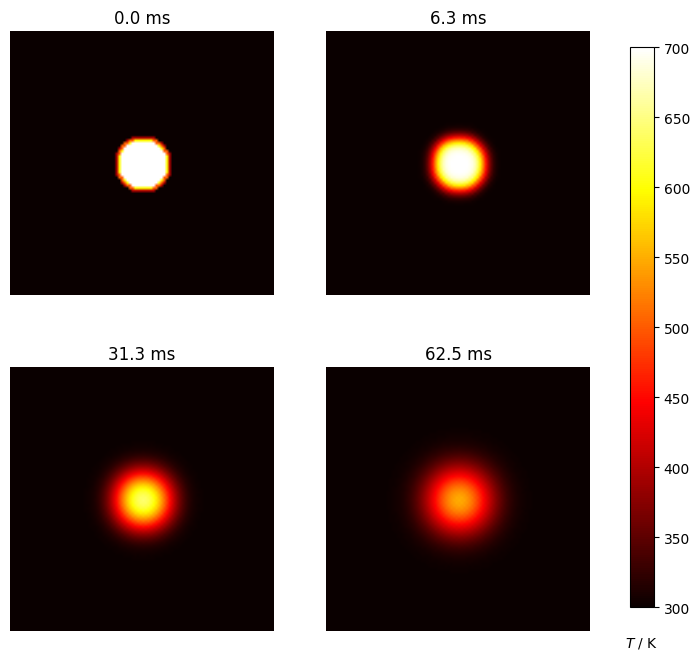

In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt

# plate size, mm
w = h = 10.0
# intervals in x-, y- directions, mm
dx = dy = 0.1
# Thermal diffusivity of steel, mm2.s-1
D = 4.0 #D=1/alpha

Tcool, Thot = 300, 700

nx, ny = int(w / dx), int(h / dy)

dx2, dy2 = dx * dx, dy * dy
dt = dx2 * dy2 / (2 * D * (dx2 + dy2)) #maximun t allowed

u0 = Tcool * np.ones((nx, ny)) #init grid (100x100) in 300K
u = u0.copy()

# Initial conditions: circle of radius r centred at (cx,cy) (mm)
r, cx, cy = 1, 5, 5
r2 = r**2
for i in range(nx):
    for j in range(ny):
        p2 = (i * dx - cx) ** 2 + (j * dy - cy) ** 2
        if p2 < r2:
            u0[i, j] = Thot

def do_timestep(u0, u):
    # Propagate with forward-difference in time, central-difference in space. Notice that dx=dy
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D*dt*(u0[2:, 1:-1] - 4 * u0[1:-1, 1:-1] + u0[:-2, 1:-1] + u0[1:-1, 2:] + u0[1:-1, :-2])/dx2

    u0 = u.copy()
    return u0, u

# Number of timesteps.
nsteps = 101
# Output 4 figures at these timesteps.
mfig = [0, 10, 50, 100]
fignum = 0
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8) )
for m in range(nsteps):
    u0, u = do_timestep(u0, u)
    if m in mfig:
        #print(m, fignum)
        ax = axes[fignum // 2, fignum % 2]
        im = ax.imshow(
            u.copy(),
            cmap="hot",
            vmin=Tcool,
            vmax=Thot,
            interpolation="bilinear",
        )
        ax.set_axis_off()
        ax.set_title("{:.1f} ms".format(m * dt * 1000))
        fignum += 1
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

## 3. Wave's equation

\begin{align}
\boxed{
\nabla^2 u(x,y,t)= \dfrac{1}{v^2}\dfrac{\partial^2 u(x,y,t)}{\partial t^2}}
\end{align}